# Portfolio Analytics Using Python
#This project analyzes the performance of a portfolio of equities using Python.
It evaluates returns, risk, and diversification using key financial metrics
such as volatility, Sharpe ratio, and correlation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf


## Objective

The objective of this project is to:

- Analyze portfolio returns and risk
- Understand diversification using correlation
- Evaluate performance using Sharpe ratio
- Compare stock performance using normalized prices

In [3]:
stocks = ["RELIANCE.NS","HDFCBANK.NS","TCS.NS"]

## Data Collection

Historical stock data was fetched using yfinance for:

- Reliance Industries
- HDFC Bank
- Tata Consultancy Services

Time period: 2016 onwards

In [4]:
data = yf.download(stocks, start="2016-01-01")
close = data['Close']

[*********************100%***********************]  3 of 3 completed


In [5]:
# Returns
returns = close.pct_change()

## Portfolio Construction

A portfolio was created with the following weights:

- Reliance: 40%
- HDFC Bank: 30%
- TCS: 30%

In [6]:
weights = np.array([0.4, 0.3, 0.3])

In [7]:
portfolio_returns = returns.dot(weights)

## Risk & Performance Metrics

The following metrics were calculated:

- Annual Return
- Volatility (Risk)
- Sharpe Ratio

Volatility measures the variability of returns,
while Sharpe ratio evaluates return per unit of risk.

In [8]:
annual_return = portfolio_returns.mean() * 252
annual_volatility = portfolio_returns.std() * (252 ** 0.5)
sharpe_ratio = annual_return / annual_volatility

print("Annual Return:", annual_return)
print("Volatility:", annual_volatility)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.1534127633422424
Volatility: 0.17745867942847202
Sharpe Ratio: 0.8644985065612316


In [9]:
cumulative = (1 + portfolio_returns).cumprod()

In [10]:
cumulative.head()

Date
2016-01-01         NaN
2016-01-04    0.981561
2016-01-05    0.978938
2016-01-06    0.992656
2016-01-07    0.981839
dtype: float64

## Visualization

The following visualizations were used:

- Portfolio growth over time
- Correlation heatmap
- Normalized stock price comparison

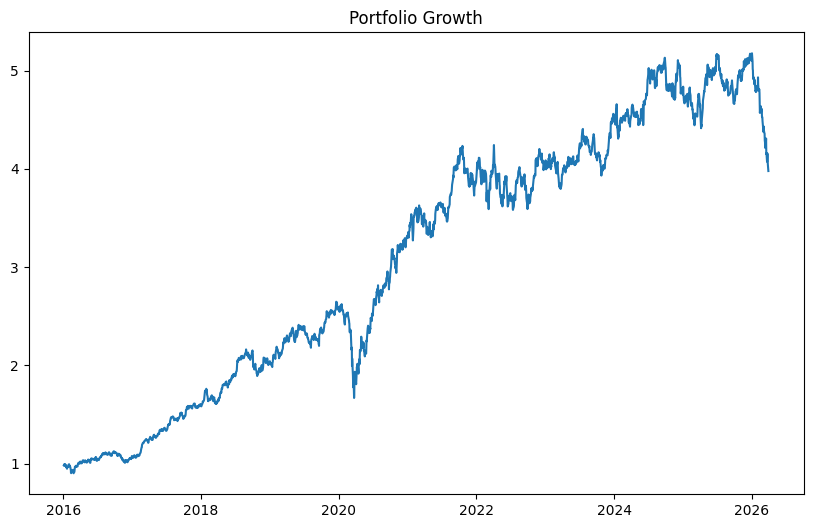

In [11]:
plt.figure(figsize=(10,6))
plt.plot(cumulative)
plt.title("Portfolio Growth")
plt.show()

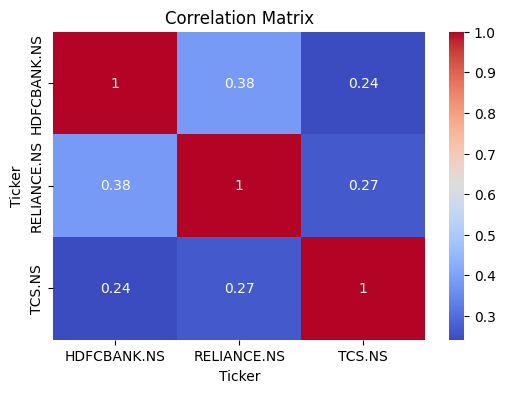

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
normalized = close / close.iloc[0] * 100

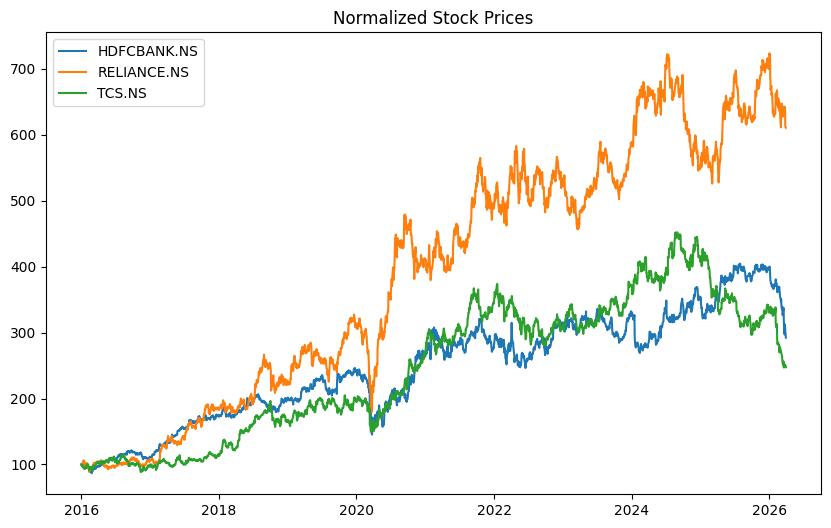

In [14]:
plt.figure(figsize=(10,6))
plt.plot(normalized)
plt.title("Normalized Stock Prices")
plt.legend(normalized.columns)
plt.show()

## Key Insights

- The portfolio generated an annual return of approximately 15.3%, indicating strong overall performance over the selected period.

- The portfolio volatility was around 17.7%, suggesting a moderate level of risk.

- The Sharpe ratio of 0.86 indicates moderate risk-adjusted performance, meaning the portfolio delivers reasonable returns relative to the risk taken.

- The correlation between stocks ranges from 0.24 to 0.38, which is relatively low. This indicates that the stocks do not move closely together, providing diversification benefits.

- Due to low correlation, the overall portfolio risk is reduced compared to holding individual stocks, demonstrating the effectiveness of diversification.

- The portfolio shows a steady growth trend over time, as observed in the cumulative return chart.

- Among the selected stocks, Reliance delivered the best performance based on normalized returns.